In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from model import telescope

from IPython.display import clear_output

import utils

import toml

import copy

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
!nvidia-smi

Sun May  3 17:44:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   32C    P0             63W /  300W |    4521MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## SETUP MODEL

In [3]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

sys = telescope(config=config, optic_opd_data=optic_opd_data)

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

for i, im in enumerate(images):
    print(f'Image {i + 1:02.0f} SNR = {im.max() / dark.std():.1f}')

Image 01 SNR = 569.3
Image 02 SNR = 1091.7
Image 03 SNR = 605.2
Image 04 SNR = 1296.5
Image 05 SNR = 712.4
Image 06 SNR = 760.1
Image 07 SNR = 1213.2


## PLOT PSFS

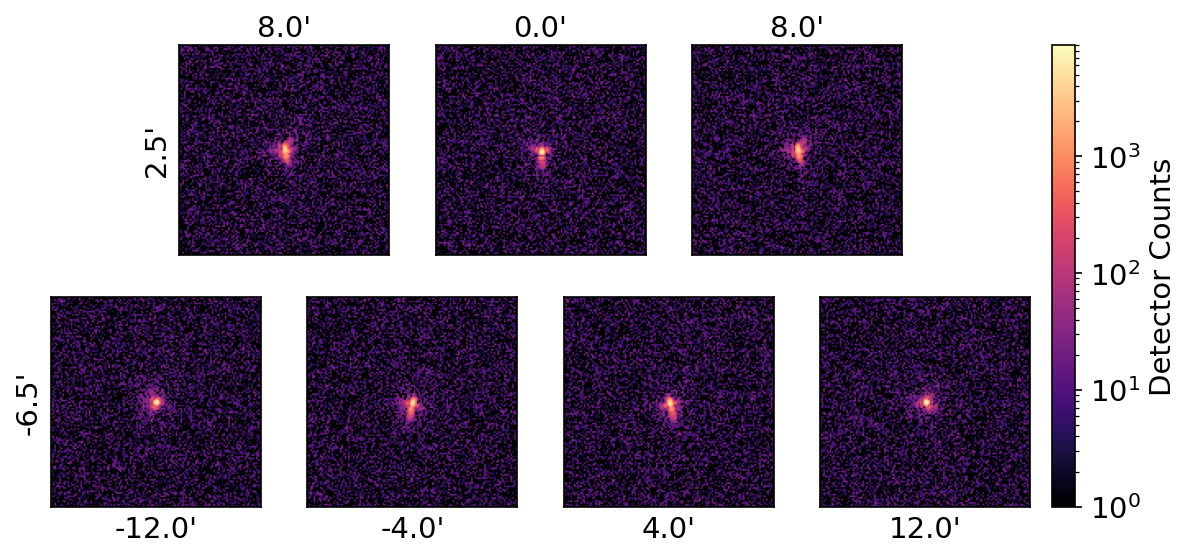

In [4]:
pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_psfs_7(psfs=images, fields=fields)

## PLOT WFES

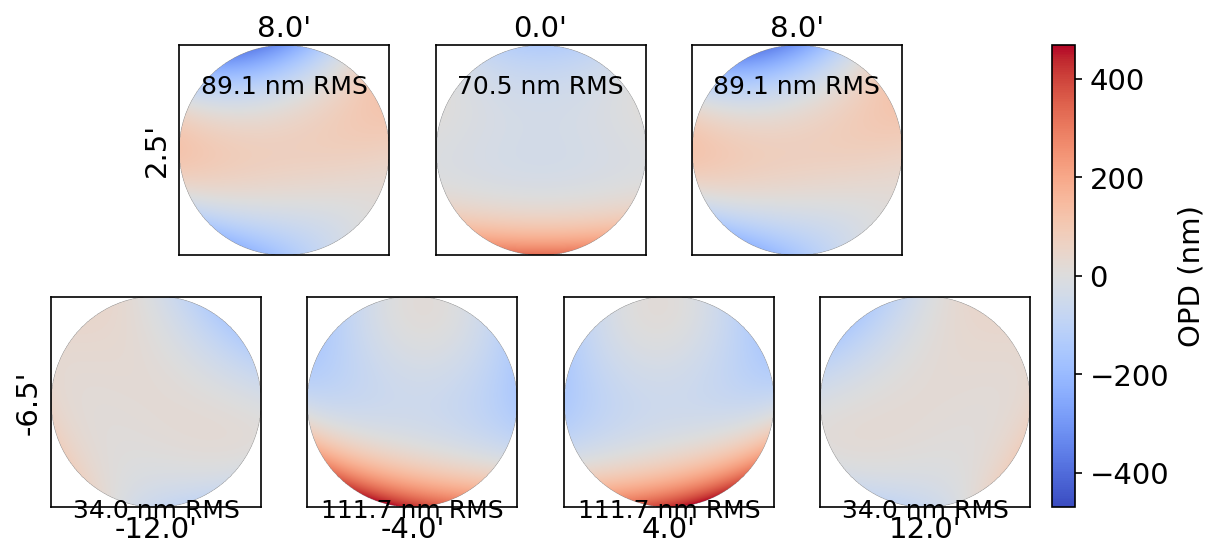

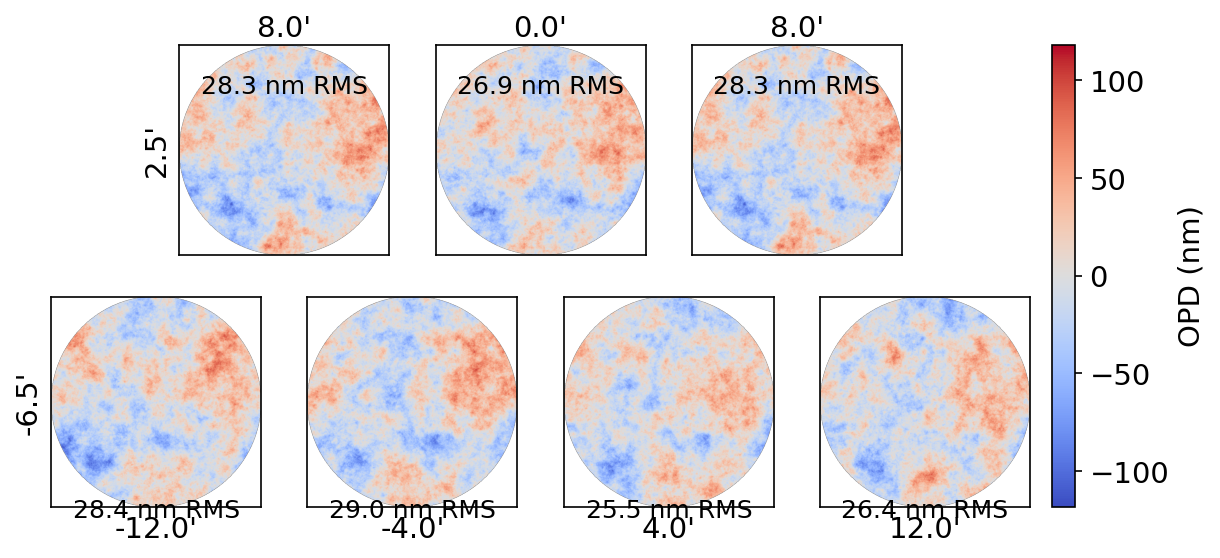

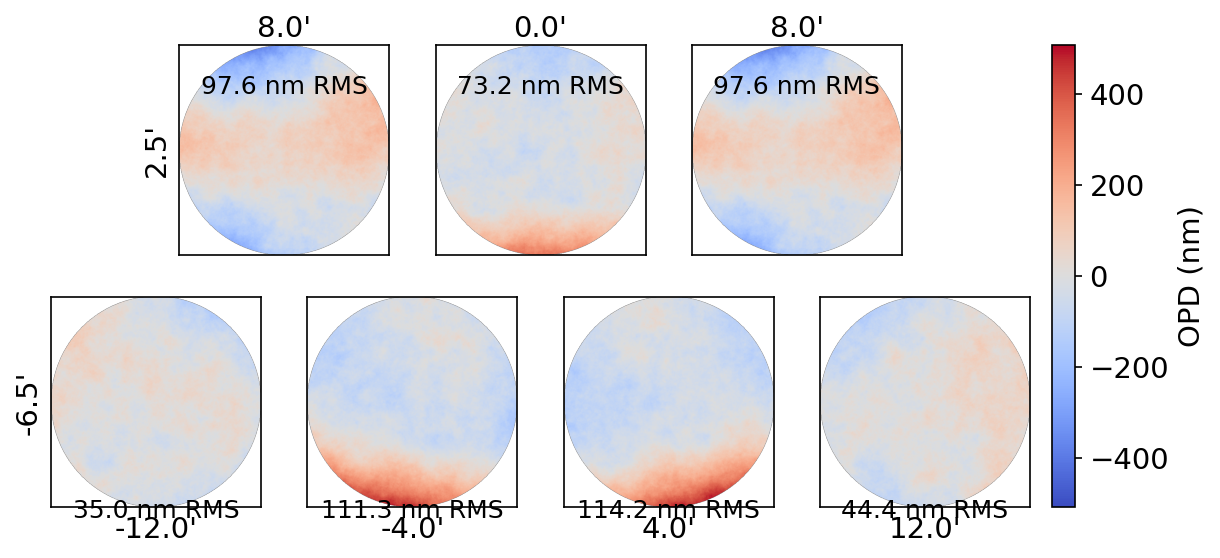

In [5]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_total = [opd_field + opd_optic for opd_field, opd_optic in zip(opds_fields, opds_optics)]

utils.plot_opds_7(opds=opds_fields, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_optics, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_total, pupil=pupil, fields=fields)

## MISALIGNMENT GENERATOR FUNCTION

In [23]:
def generate_misalignment(range_decenter, range_tilt, rng):
    
    M1_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 4, high=range_decenter / 4),
                                  'y' : rng.uniform(low=-range_decenter / 4, high=range_decenter / 4),
                                  'y' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 4, high=range_tilt / 4),
                                  'tilt' : rng.uniform(low=-range_tilt / 4, high=range_tilt / 4),}}

    M2_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),
                                  'tilt' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),}}
    
    M3_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),
                                  'tilt' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),}}
    
    M4_motion = {'user_motion' : {'x' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : rng.uniform(low=-range_decenter / 2, high=range_decenter / 2),
                                  'y' : 0,
                                  'tip' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),
                                  'tilt' : rng.uniform(low=-range_tilt / 2, high=range_tilt / 2),}}
    
    return {'M1' : M1_motion,
            'M2' : M2_motion,
            'M3' : M3_motion,
            'M4' : M4_motion}

## GENERATE AND SAVE CASES

In [24]:
n = 100
misalignments = []

range_decenter = 100e-6  / 2# 50 um
range_tilt = 4.84814e-5  / 2# 5 arcsec (converted to rad for raytrace model)

# set seed for repeatability WYSI
rng_np = _np.random.default_rng(seed=727)

for _ in range(n):
    misalignments.append(generate_misalignment(range_decenter=range_decenter, range_tilt=range_tilt, rng=rng_np))

utils.save_pickle('/home/derbyk/src/ffpr/data/misalignment_cases_100_dec_50um_tilt_5as_M1_less.pkl', data=misalignments)

Saved data to:  /home/derbyk/src/ffpr/data/misalignment_cases_100_dec_50um_tilt_5as_M1_less.pkl


## VISUALIZE

In [25]:
misalignments = utils.load_pickle('/home/derbyk/src/ffpr/data/misalignment_cases_100_dec_50um_tilt_5as_M1_less.pkl')

In [26]:
rms_of_rms = []
rms_of_pv = []

for m in misalignments:

    sys.move_optics(M1_motion=m['M1'], M2_motion=m['M4'], M3_motion=m['M4'], M4_motion=m['M4'])

    opds_fields = copy.deepcopy(sys.opds_field)
    opds_optics = copy.deepcopy(sys.opds_optics)
    opds_total = [opd_field + opd_optic for opd_field, opd_optic in zip(opds_fields, opds_optics)]

    rms_per_field = []
    pv_per_field = []

    for opd in opds_total:
        opd -= np.mean(opd[pupil])
        rms_per_field.append(np.sqrt(np.mean(opd[pupil] ** 2)))
        pv_per_field.append(np.max(opd[pupil]) - np.min(opd[pupil]))

    rms_of_rms.append(np.sqrt(np.mean(np.array(rms_per_field) ** 2)))
    rms_of_pv.append(np.sqrt(np.mean(np.array(pv_per_field) ** 2)))

Text(0, 0.5, 'Count')

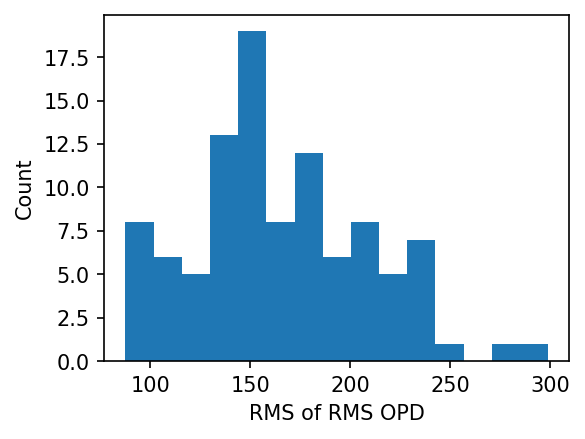

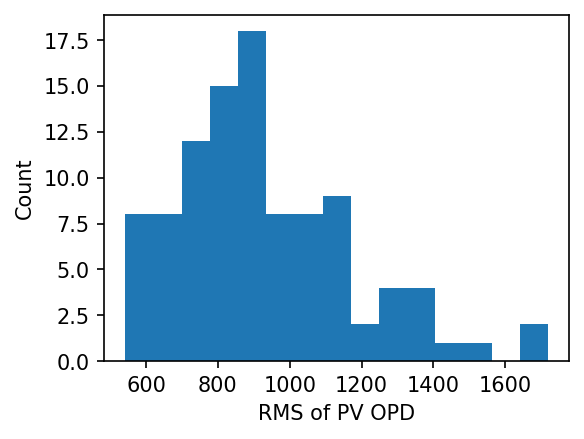

In [28]:
plt.figure(figsize=(4, 3), dpi=150)
plt.hist(x=np.array(rms_of_rms).get(), bins=15)
plt.xlabel('RMS of RMS OPD')
plt.ylabel('Count')

plt.figure(figsize=(4, 3), dpi=150)
plt.hist(x=np.array(rms_of_pv).get(), bins=15)
plt.xlabel('RMS of PV OPD')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

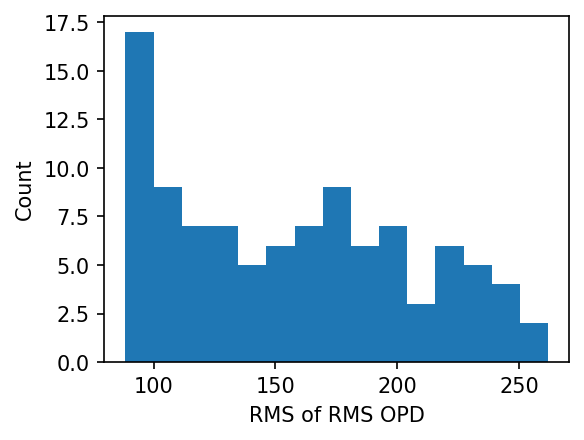

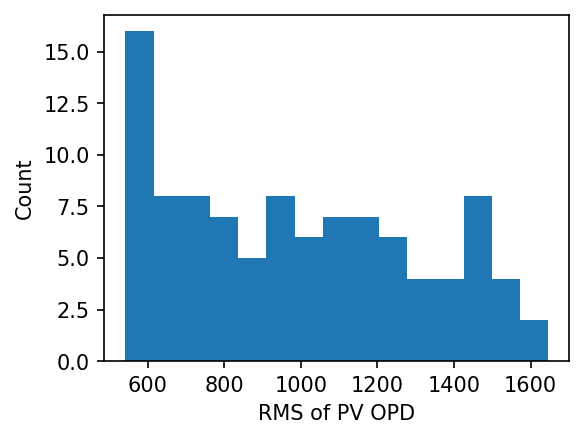

In [55]:
plt.figure(figsize=(4, 3), dpi=150)
plt.hist(x=np.array(rms_of_rms).get(), bins=15)
plt.xlabel('RMS of RMS OPD')
plt.ylabel('Count')

plt.figure(figsize=(4, 3), dpi=150)
plt.hist(x=np.array(rms_of_pv).get(), bins=15)
plt.xlabel('RMS of PV OPD')
plt.ylabel('Count')